# Cape Cauldron coherent vortices

The Cape Cauldron, the Agulhas-ring corridor south-west of South Africa, is
the textbook setting for coherent Lagrangian vortices: Haller & Beron-Vera
(2013, [doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391))
found them here with the same $\eta_\lambda$ construction this notebook uses.

The FTLE ridges in `cabo_verde_ftle` mark hyperbolic stretching. A coherent
Lagrangian vortex is a different structure, a region that stays together as it
advects, bounded by a material curve that stretches uniformly.
Haller (2015, §5.2 / Table 1, row "Shear",
[doi:10.1146/annurev-fluid-010313-141322](https://doi.org/10.1146/annurev-fluid-010313-141322))
builds such curves from the same Cauchy–Green tensor
$C = (\nabla F)^\top \nabla F$, eigenpairs $C\xi_i = \lambda_i \xi_i$,
$0 < \lambda_1 \le \lambda_2$. A *shear line* is tangent everywhere to
(Eq. 11)

$$
\eta^{\pm} = \sqrt{\frac{\sqrt{\lambda_2}}{\sqrt{\lambda_1}+\sqrt{\lambda_2}}}\,\xi_1
  \;\pm\; \sqrt{\frac{\sqrt{\lambda_1}}{\sqrt{\lambda_1}+\sqrt{\lambda_2}}}\,\xi_2 \,.
$$

A closed shear line is an **elliptic LCS**; the outermost member of a nested
family of closed shear lines is the boundary of a coherent Lagrangian vortex.
Eq. 11 keeps a material curve's arc length fixed under an area-preserving
flow. The Cape Cauldron surface flow is not area-preserving over 15 days, so
this notebook uses the $\lambda$-generalisation instead (Haller & Beron-Vera 2013,
Eq. 14,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)):

$$
\eta_\lambda^{\pm} = \sqrt{\frac{\lambda_2 - \lambda^2}{\lambda_2 - \lambda_1}}\,\xi_1
  \;\pm\; \sqrt{\frac{\lambda^2 - \lambda_1}{\lambda_2 - \lambda_1}}\,\xi_2 \,,
$$

well defined only where $\lambda_1 < \lambda^2 < \lambda_2$. It satisfies
$|\nabla F\,\eta_\lambda| = \lambda$ at every point, so a curve tangent to
it has its arc length multiplied by $\lambda$ over the window, and a closed
orbit of $\eta_\lambda$ is a uniformly stretching material loop. Eq. 11 is
Eq. 14 at $\lambda = 1$ where the flow is area-preserving, so
$\lambda_1\lambda_2 = 1$. This notebook scans a set of $\lambda$ around 1 and
both signs, since the boundary can show up at any of them.

Detection follows Haller & Beron-Vera (2013). A short Poincaré section runs
through a candidate centre, $\eta_\lambda$ lines are launched along it and
integrated to their first return, and the return map $s \mapsto P(s)$ is read
off the section. A fixed point $P(s) = s$ is a closed orbit.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.path import Path as MplPath
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4
from scipy.interpolate import RegularGridInterpolator

from lcs_parcels import NeighborSeedGrid
from lcs_parcels.grids import _M_PER_DEG, _separation_m
from lcs_parcels.tensorlines import _step_lonlat_by_meters

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_15086/590446562.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

The local file that `get_data` writes.

In [2]:
currents = xr.open_dataset("data/cape_cauldron_currents_hourly.nc").load()
currents

<xarray.Dataset> Size: 120MB
Dimensions:    (time: 409, depth: 1, latitude: 169, longitude: 217)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2025-05-31 ... 2025-06-17
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 676B -43.0 -42.92 -42.83 ... -29.08 -29.0
  * longitude  (longitude) float32 868B 3.0 3.083 3.167 ... 20.83 20.92 21.0
Data variables:
    uo         (time, depth, latitude, longitude) float32 60MB 0.1873 ... nan
    vo         (time, depth, latitude, longitude) float32 60MB 0.1156 ... nan
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     hourly mean fields from Global Ocean Physics A...
    copernicusmarine_version:  2.4.1

## Parcels v4 field set

`copernicusmarine_to_sgrid` tags the CMEMS A-grid with SGRID metadata;
`from_sgrid_conventions` wraps it as a spherical `FieldSet`.

In [3]:
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed grid and window

A box across the Cape Cauldron, released on 2025-06-01 and advected 15 days
forward, long enough for an Agulhas ring (100-300 km across) to complete
several revolutions. Only the forward flow map is needed, since a vortex
boundary is a property of one time window, not of the forward/backward pair
`cabo_verde_lcs` uses for repelling/attracting duality.

In [4]:
t0 = np.datetime64("2025-06-01")
T = np.timedelta64(15, "D")
resolution_deg = 1 / 25
seed_lon, seed_lat = (6.0, 18.0), (-40.0, -32.0)

lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeedGrid.from_axes(lon=lon_axis, lat=lat_axis)
seed

<NeighborSeedGrid 301x201 grid, lon 6.00..18.00, lat -40.00..-32.00>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. `StatusCode.EndofLoop` rather than
`StatusCode.Delete`: deleting shrinks the particle array and breaks the
alignment with the seed order.

In [5]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect forward

In [6]:
lon, lat = seed.to_parcels_pset()
z = np.full(len(lon), z_surface)
pset = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)
forward = seed.pset_to_flowmap(lon=pset.x, lat=pset.y, t0=t0, t1=t0 + T)
forward

<NeighborFlowMap 301x201 grid, lon 6.00..18.00, lat -40.00..-32.00,
                 t0 2025-06-01T00:00:00, T +15.0 days>

## Eigendecomposition and FTLE

`cg_eigen` carries $\lambda_1,\lambda_2$ and $\xi_1,\xi_2$ together; `ftle`
is the backdrop the candidate centres and the closed orbits are shown
against below.

In [7]:
eigen = forward.cg_eigen()
eigen

<xarray.Dataset> Size: 4MB
Dimensions:   (i: 301, j: 201, eig: 2, comp: 2)
Coordinates:
  * i         (i) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299 300
  * j         (j) int64 2kB 0 1 2 3 4 5 6 7 ... 193 194 195 196 197 198 199 200
    lon_grid  (i, j) float64 484kB 6.0 6.0 6.0 6.0 6.0 ... 18.0 18.0 18.0 18.0
    lat_grid  (i, j) float64 484kB -40.0 -39.96 -39.92 ... -32.08 -32.04 -32.0
  * eig       (eig) int64 16B 0 1
  * comp      (comp) <U1 8B 'x' 'y'
    t0        datetime64[s] 8B 2025-06-01
    T         timedelta64[s] 8B 15 days
Data variables:
    lambda    (i, j, eig) float64 968kB nan nan nan nan nan ... nan nan nan nan
    xi        (i, j, comp, eig) float64 2MB nan nan nan nan ... nan nan nan nan

In [8]:
ftle = forward.ftle()
ftle

<xarray.DataArray 'ftle' (i: 301, j: 201)> Size: 484kB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan, 1.18163228e-06, 7.67648536e-07, ...,
        8.86267524e-07, 9.02526180e-07,            nan],
       [           nan, 1.20001299e-06, 7.89137985e-07, ...,
        7.94346975e-07, 6.48747474e-07,            nan],
       ...,
       [           nan,            nan,            nan, ...,
        9.23628838e-07, 5.99216206e-07,            nan],
       [           nan,            nan,            nan, ...,
        9.30582829e-07, 6.89954393e-07,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], shape=(301, 201))
Coordinates:
  * i         (i) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299 300
  * j         (j) int64 2kB 0 1 2 3 4 5 6 7 ... 193 194 195 196 197 198 199 200
    lon_grid  (i, j) float64 484kB 6.0 6.0 6.0 6.0 6.0 ... 18.0 18.0 18.0 18.0
    lat_grid  (i, j) float64 484kB -40.0 -39.96 -39.92 ... -32.08 -32.04 -32.0
    t0        datetime64[s] 8B 2025-06-01
    T         timedelta64[s] 8B 15 days
Attributes:
    long_name:  finite-time Lyapunov exponent
    units:      1/s

## The $\eta_\lambda$ tangent field

`shrink_lines` traces $\xi_1$ and takes no caller-supplied tangent field, so
the $\eta_\lambda$ field is built here. It follows the same scheme as the
library tracer, interpolating $C$ itself rather than the eigenvectors and
re-diagonalising at every evaluation.

$\xi_1$ and $\xi_2$ each carry a sign that `eigh` picks arbitrarily, and
flipping $\xi_2$ alone turns $\eta^+$ into $\eta^-$. The two signs are tied
together below so the two branches stay apart.

In [9]:
lon_grid_axis = forward.lon_grid.isel(j=0).values
lat_grid_axis = forward.lat_grid.isel(i=0).values
CG_grid = forward.cauchy_green().transpose("i", "j", "row", "col").values
tensor_interp = RegularGridInterpolator(
    (lon_grid_axis, lat_grid_axis), CG_grid, bounds_error=False, fill_value=np.nan
)


def eta_lambda_tangent(lon, lat, heading, *, lam, sign, tensor_interp):
    """Unit eta_lambda^{sign} (Haller & Beron-Vera 2013, Eq. 14) at each point.

    NaN wherever off-grid, in a NaN cell, or lam**2 does not sit strictly
    inside (lambda_1, lambda_2), the well-definedness condition for eta_lambda.
    """
    C = tensor_interp(np.column_stack([lon, lat]))
    terminated = ~np.isfinite(C).all(axis=(1, 2))
    eigenvalues, eigenvectors = np.linalg.eigh(
        np.where(terminated[:, None, None], np.eye(2), C)
    )
    lam1, lam2 = np.maximum(eigenvalues[:, 0], 0.0), eigenvalues[:, 1]
    well_defined = (lam1 < lam**2) & (lam**2 < lam2)
    terminated = terminated | ~well_defined
    denom = np.maximum(lam2 - lam1, 1e-30)
    a = np.sqrt(np.clip((lam2 - lam**2) / denom, 0.0, 1.0))
    b = np.sqrt(np.clip((lam**2 - lam1) / denom, 0.0, 1.0))
    xi1 = eigenvectors[:, :, 0]
    # eigh signs each eigenvector on its own, and flipping xi_2 alone turns
    # eta^+ into eta^-. Taking xi_2 as xi_1 turned 90 degrees counter-clockwise
    # ties the two signs together, so the two branches stay distinct.
    xi2 = np.column_stack([-xi1[:, 1], xi1[:, 0]])
    eta = a[:, None] * xi1 + sign * b[:, None] * xi2
    # Negating xi_1 negates xi_2 with it, so eta is fixed up to one overall
    # sign, and orienting it to the running heading stays inside one branch.
    eta[np.sum(eta * heading, axis=1) < 0] *= -1
    eta[terminated] = np.nan
    return eta

## RK2 tracer

Marches $\eta_\lambda$ one direction from a set of launch points with the
midpoint (RK2) scheme `shrink_lines` uses. The spherical step
`_step_lonlat_by_meters` is imported from `lcs_parcels.tensorlines`, where it
is private, since the package exposes no public tangent-field stepper.

In [10]:
def trace_eta_lines(lon0, lat0, *, lam, sign, step_m, n_steps, tensor_interp):
    lon = np.asarray(lon0, dtype=float).ravel().copy()
    lat = np.asarray(lat0, dtype=float).ravel().copy()
    heading = eta_lambda_tangent(
        lon,
        lat,
        np.ones((lon.size, 2)),
        lam=lam,
        sign=sign,
        tensor_interp=tensor_interp,
    )
    dead = ~np.isfinite(heading).all(axis=1)
    lon[dead], lat[dead] = np.nan, np.nan
    track_lon, track_lat = [lon.copy()], [lat.copy()]
    for _ in range(n_steps):
        direction = eta_lambda_tangent(
            lon, lat, heading, lam=lam, sign=sign, tensor_interp=tensor_interp
        )
        mid_lon, mid_lat = _step_lonlat_by_meters(
            lon, lat, 0.5 * direction, step_m=step_m
        )
        mid_direction = eta_lambda_tangent(
            mid_lon, mid_lat, direction, lam=lam, sign=sign, tensor_interp=tensor_interp
        )
        lon, lat = _step_lonlat_by_meters(lon, lat, mid_direction, step_m=step_m)
        heading = mid_direction
        track_lon.append(lon.copy())
        track_lat.append(lat.copy())
    return np.array(track_lon), np.array(track_lat)  # (n_steps + 1, n)

## Where $\eta_\lambda$ is well defined, at $\lambda = 1$

$\eta_1$ needs $\lambda_1 < 1 < \lambda_2$, so a neighbourhood has to be
stretched in one eigendirection and contracted in the other. Where it is not,
there is no direction of stretch factor 1 and a traced line ends.

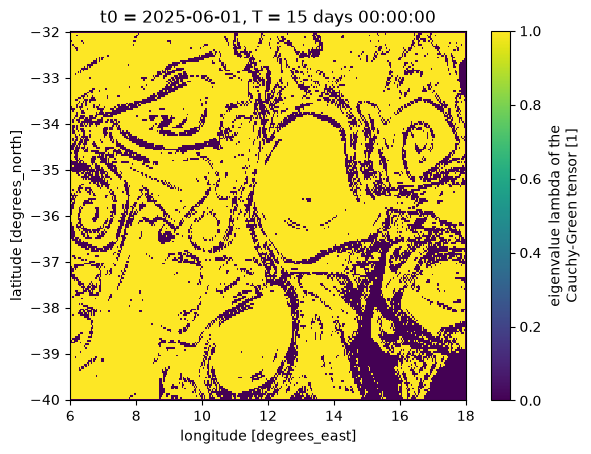

In [11]:
lambda1 = eigen["lambda"].isel(eig=0)
lambda2 = eigen["lambda"].isel(eig=1)
well_defined = (lambda1 < 1.0) & (1.0 < lambda2)
well_defined.plot.pcolormesh(x="lon_grid", y="lat_grid")

## How far from area-preserving

$\sqrt{\lambda_1\lambda_2} = |\det \nabla F|$ is the area change over the
window, and a boundary enclosing it stretches by about its square root. The
quantiles below set the $\lambda$ range the sweep scans.

In [12]:
det_grad_F = np.sqrt(lambda1 * lambda2)
det_grad_F.quantile([0.05, 0.25, 0.5, 0.75, 0.95])

<xarray.DataArray 'lambda' (quantile: 5)> Size: 40B
array([  0.18031875,   0.68992638,   1.4264817 ,   7.95071094,
       164.68792314])
Coordinates:
  * quantile  (quantile) float64 40B 0.05 0.25 0.5 0.75 0.95
Attributes:
    long_name:  eigenvalue lambda of the Cauchy-Green tensor
    units:      1

## Candidate vortex centres

A coherent vortex core is where material barely stretches at all in either
eigendirection, so $\lambda_2$ (the larger, more discriminating of the two)
is at a local minimum. `find_centres` below is the `ftle_ridge_seeds`
windowed-extremum trick inverted to a minimum, plus a validity guard that
keeps a centre 50 km from the domain edge and from any NaN (land) cell,
since the tensor there is unreliable. The window is 200 km, about the
radius of the rings this box targets, so a genuine core is not split into
several spurious local minima.

In [13]:
def find_centres(field, *, window_m, edge_m):
    lon_grid, lat_grid = field["lon_grid"], field["lat_grid"]
    dx, _ = _separation_m(
        lon_a=lon_grid.shift(i=1),
        lat_a=lat_grid.shift(i=1),
        lon_b=lon_grid,
        lat_b=lat_grid,
    )
    _, dy = _separation_m(
        lon_a=lon_grid.shift(j=1),
        lat_a=lat_grid.shift(j=1),
        lon_b=lon_grid,
        lat_b=lat_grid,
    )
    spacing_i, spacing_j = float(np.abs(dx).median()), float(np.abs(dy).median())
    cells_i = max(
        1, round(window_m / spacing_i) - (round(window_m / spacing_i) % 2 == 0)
    )
    cells_j = max(
        1, round(window_m / spacing_j) - (round(window_m / spacing_j) % 2 == 0)
    )
    local_min = field.rolling(i=cells_i, j=cells_j, center=True, min_periods=1).min()
    is_centre = field <= local_min

    edge_cells_i = int(np.ceil(edge_m / spacing_i))
    edge_cells_j = int(np.ceil(edge_m / spacing_j))
    ni, nj = field.sizes["i"], field.sizes["j"]
    valid_window = (
        field.notnull()
        .astype(float)
        .rolling(
            i=2 * edge_cells_i + 1, j=2 * edge_cells_j + 1, center=True, min_periods=1
        )
        .min()
    )
    i_idx, j_idx = (
        xr.DataArray(np.arange(ni), dims="i"),
        xr.DataArray(np.arange(nj), dims="j"),
    )
    near_edge = (
        (i_idx < edge_cells_i)
        | (i_idx >= ni - edge_cells_i)
        | (j_idx < edge_cells_j)
        | (j_idx >= nj - edge_cells_j)
    )
    keep = is_centre & field.notnull() & (valid_window > 0.5) & ~near_edge
    picked = (
        xr.Dataset({"lon": lon_grid, "lat": lat_grid, "value": field})
        .stack(pt=("i", "j"))
        .where(keep.stack(pt=("i", "j")), drop=True)
    )
    return picked["lon"].values, picked["lat"].values, picked["value"].values

In [14]:
centre_lon, centre_lat, centre_lambda2 = find_centres(
    lambda2, window_m=200_000.0, edge_m=50_000.0
)
len(centre_lon)

16

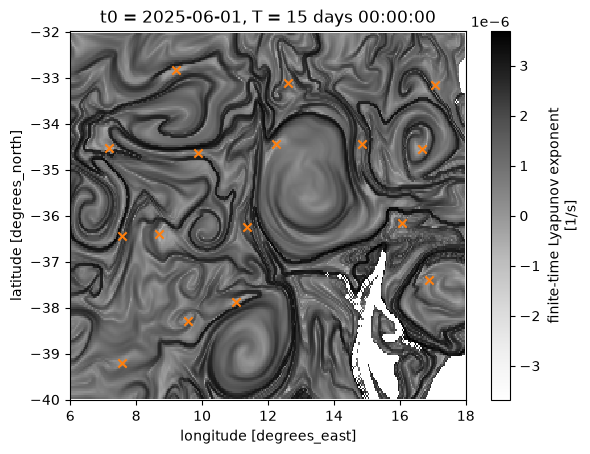

In [15]:
fig, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.scatter(centre_lon, centre_lat, marker="x", color="tab:orange")
plt.show()

## Poincaré section and return map

The section runs due east from a candidate centre. `first_return` walks each
traced line and finds the first crossing of the section after the line has
moved away from it, linearly interpolating the crossing longitude. Both `s`
and `P(s)` are arc length east of the centre, and a zero of $P(s) - s$ is a
closed orbit.

In [16]:
SECTION_LENGTH_M = 250_000.0
N_LAUNCH = 50
STEP_M = 2_000.0
RING_DIAMETER_M = 300_000.0  # the largest ring size this box targets
BUDGET_M = 2 * np.pi * (RING_DIAMETER_M / 2) * 2  # two circumferences
N_STEPS = round(BUDGET_M / STEP_M)
LAMBDAS = list(np.linspace(0.8, 1.4, 7))
SIGNS = [+1, -1]
CLOSE_TOL_M = 2_000.0


def section_points(centre_lon, centre_lat, length_m, n):
    s = np.linspace(0.0, length_m, n)
    lon = centre_lon + s / (_M_PER_DEG * np.cos(np.deg2rad(centre_lat)))
    lat = np.full(n, centre_lat)
    return s, lon, lat


def first_return(
    track_lon, track_lat, *, section_lat, section_lon_min, section_lon_max
):
    """First crossing of the section segment after the line has moved off it.

    Returns the crossing longitude, NaN where the line never comes back, and
    the number of track points up to and including the crossing step. A line
    encircling the centre also crosses the section latitude west of it, outside
    the segment; that is not a return, and the scan runs on.
    """
    n_steps_p1, n_lines = track_lon.shape
    north_rel = track_lat - section_lat
    result_lon = np.full(n_lines, np.nan)
    cut = np.full(n_lines, n_steps_p1, dtype=int)
    for k in range(n_lines):
        lon_k, rel_k = track_lon[:, k], north_rel[:, k]
        started_away = False
        for i in range(1, n_steps_p1):
            if not (np.isfinite(rel_k[i]) and np.isfinite(lon_k[i])):
                break
            if not started_away:
                started_away = abs(rel_k[i]) > 1e-9
                continue
            if rel_k[i - 1] == 0 or (np.sign(rel_k[i - 1]) != np.sign(rel_k[i])):
                t = rel_k[i - 1] / (rel_k[i - 1] - rel_k[i])
                lon_cross = lon_k[i - 1] + t * (lon_k[i] - lon_k[i - 1])
                if section_lon_min - 1e-6 <= lon_cross <= section_lon_max + 1e-6:
                    result_lon[k], cut[k] = lon_cross, i + 1
                    break
    return result_lon, cut

In [17]:
c_lon, c_lat = centre_lon[0], centre_lat[0]
s_vals, launch_lon, launch_lat = section_points(
    c_lon, c_lat, SECTION_LENGTH_M, N_LAUNCH
)
track_lon, track_lat = trace_eta_lines(
    launch_lon,
    launch_lat,
    lam=1.0,
    sign=+1,
    step_m=STEP_M,
    n_steps=N_STEPS,
    tensor_interp=tensor_interp,
)
ret_lon, _ = first_return(
    track_lon,
    track_lat,
    section_lat=c_lat,
    section_lon_min=launch_lon.min(),
    section_lon_max=launch_lon.max(),
)
ret_s = (ret_lon - c_lon) * _M_PER_DEG * np.cos(np.deg2rad(c_lat))

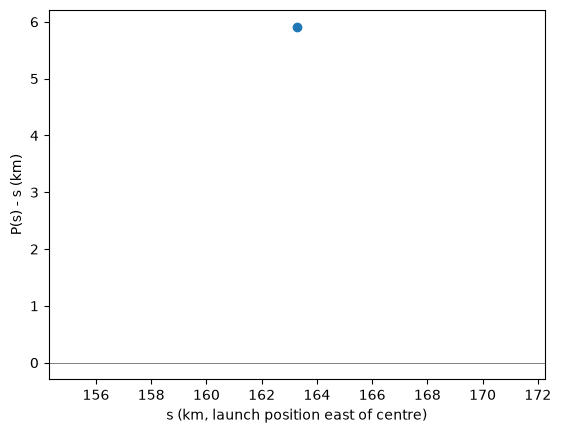

In [18]:
fig, ax = plt.subplots()
ax.plot(s_vals / 1000, (ret_s - s_vals) / 1000, marker="o")
ax.axhline(0, color="grey", lw=0.7)
ax.set_xlabel("s (km, launch position east of centre)")
ax.set_ylabel("P(s) - s (km)")
plt.show()

## Closed orbits over all $\lambda$ and signs

For every candidate centre, every $\lambda$ and both signs of $\eta_\lambda$:
find the sign changes of $P(s) - s$ across neighbouring launch points,
refine each by linear interpolation, re-trace from the refined $s$, and
accept it as a closed orbit when the residual return displacement is under
`CLOSE_TOL_M`.

A residual-only check accepts a line that merely grazes back across the
section without enclosing the centre, so every candidate also has to enclose
the centre and have a circumference within a factor of 2 of $2\pi r$ for its
mean radius $r$.

The sweep also records, for each combination, how far around the centre its
best launch point gets before the line ends. A closed orbit needs a full
revolution, so that number bounds what the search can find.

In [19]:
def revolutions(track_lon, track_lat, *, centre_lon, centre_lat):
    """Turns each traced line makes about the centre before it terminates."""
    dx, dy = _separation_m(
        lon_a=centre_lon, lat_a=centre_lat, lon_b=track_lon, lat_b=track_lat
    )
    angle = np.unwrap(np.arctan2(dy, dx), axis=0)
    turns = np.full(track_lon.shape[1], np.nan)
    for k in range(track_lon.shape[1]):
        finite = np.isfinite(angle[:, k])
        if finite.sum() > 1:
            ends = angle[finite, k]
            turns[k] = (ends[-1] - ends[0]) / (2 * np.pi)
    return turns

In [20]:
def sweep_centres(centre_lon, centre_lat, lambdas, signs):
    """Closed-orbit search over every candidate centre, lambda and sign."""
    closed_orbits = []
    winding = []
    n_never_return = 0

    for ci, (cl, ca) in enumerate(zip(centre_lon, centre_lat, strict=True)):
        s_vals, launch_lon, launch_lat = section_points(
            cl, ca, SECTION_LENGTH_M, N_LAUNCH
        )
        lon_min, lon_max = launch_lon.min(), launch_lon.max()
        for lam in lambdas:
            for sign in signs:
                track_lon, track_lat = trace_eta_lines(
                    launch_lon,
                    launch_lat,
                    lam=lam,
                    sign=sign,
                    step_m=STEP_M,
                    n_steps=N_STEPS,
                    tensor_interp=tensor_interp,
                )
                turns = revolutions(track_lon, track_lat, centre_lon=cl, centre_lat=ca)
                if np.isfinite(turns).any():
                    k_best = int(np.nanargmax(np.abs(turns)))
                    winding.append(
                        {
                            "centre_idx": ci,
                            "centre_lon": cl,
                            "centre_lat": ca,
                            "lam": lam,
                            "sign": sign,
                            "s": s_vals[k_best],
                            "turns": turns[k_best],
                            "steps": int(np.isfinite(track_lon[:, k_best]).sum()),
                        }
                    )
                ret_lon, _ = first_return(
                    track_lon,
                    track_lat,
                    section_lat=ca,
                    section_lon_min=lon_min,
                    section_lon_max=lon_max,
                )
                ret_s = (ret_lon - cl) * _M_PER_DEG * np.cos(np.deg2rad(ca))
                if not np.isfinite(ret_s).any():
                    n_never_return += 1
                    continue
                P_minus_s = ret_s - s_vals
                finite = np.isfinite(P_minus_s)
                for i in range(N_LAUNCH - 1):
                    if not (finite[i] and finite[i + 1]):
                        continue
                    a, b = P_minus_s[i], P_minus_s[i + 1]
                    if not (a == 0 or np.sign(a) != np.sign(b)):
                        continue
                    t = a / (a - b)
                    s_fix = s_vals[i] + t * (s_vals[i + 1] - s_vals[i])
                    dlon = s_fix / (_M_PER_DEG * np.cos(np.deg2rad(ca)))
                    poly_lon, poly_lat = trace_eta_lines(
                        np.array([cl + dlon]),
                        np.array([ca]),
                        lam=lam,
                        sign=sign,
                        step_m=STEP_M,
                        n_steps=N_STEPS,
                        tensor_interp=tensor_interp,
                    )
                    ret_lon2, cut_arr = first_return(
                        poly_lon,
                        poly_lat,
                        section_lat=ca,
                        section_lon_min=lon_min,
                        section_lon_max=lon_max,
                    )
                    if not np.isfinite(ret_lon2[0]):
                        continue
                    ret_s2 = (ret_lon2[0] - cl) * _M_PER_DEG * np.cos(np.deg2rad(ca))
                    residual_m = abs(ret_s2 - s_fix)
                    if residual_m >= CLOSE_TOL_M:
                        continue
                    cut = int(cut_arr[0])
                    dx, dy = _separation_m(
                        lon_a=cl,
                        lat_a=ca,
                        lon_b=poly_lon[:cut, 0],
                        lat_b=poly_lat[:cut, 0],
                    )
                    radius_m = np.hypot(dx, dy)
                    mean_radius_m = float(np.nanmean(radius_m))
                    encloses = MplPath(np.column_stack([dx, dy])).contains_point(
                        (0.0, 0.0)
                    )
                    length_m = np.sum(
                        np.hypot(
                            np.diff(np.append(dx, dx[0])), np.diff(np.append(dy, dy[0]))
                        )
                    )
                    circumference_ratio = (
                        length_m / (2 * np.pi * mean_radius_m)
                        if mean_radius_m > 0
                        else np.nan
                    )
                    closed_orbits.append(
                        {
                            "centre_idx": ci,
                            "centre_lon": cl,
                            "centre_lat": ca,
                            "lam": lam,
                            "sign": sign,
                            "s": s_fix,
                            "residual_m": residual_m,
                            "lon": poly_lon[:cut, 0],
                            "lat": poly_lat[:cut, 0],
                            "mean_radius_m": mean_radius_m,
                            "encloses_centre": bool(encloses),
                            "circumference_ratio": float(circumference_ratio),
                        }
                    )
    return closed_orbits, winding, n_never_return

In [21]:
candidate_returns, winding, n_never_return = sweep_centres(
    centre_lon, centre_lat, LAMBDAS, SIGNS
)
closed_orbits = [
    o
    for o in candidate_returns
    if o["encloses_centre"] and 0.5 < o["circumference_ratio"] < 2.0
]
len(candidate_returns), len(closed_orbits), n_never_return

(0, 0, 49)

No closed orbit survives the shape filter at $\lambda \in [0.8, 1.4]$, so a
denser scan around $\lambda = 1$ is tried before giving up on this
$\lambda$ range.

In [22]:
LAMBDAS_DENSE = []
if not closed_orbits:
    LAMBDAS_DENSE = list(np.linspace(0.9, 1.2, 13))
    candidate_returns_dense, winding_dense, n_never_return_dense = sweep_centres(
        centre_lon, centre_lat, LAMBDAS_DENSE, SIGNS
    )
    closed_orbits_dense = [
        o
        for o in candidate_returns_dense
        if o["encloses_centre"] and 0.5 < o["circumference_ratio"] < 2.0
    ]
    candidate_returns += candidate_returns_dense
    winding += winding_dense
    n_never_return += n_never_return_dense
    closed_orbits += closed_orbits_dense
LAMBDAS_ALL = sorted(LAMBDAS + LAMBDAS_DENSE)
len(candidate_returns), len(closed_orbits), n_never_return

(0, 0, 145)

Neither pass over these centres closes a shape-filtered orbit, so a
different centre selection is tried next.

In [23]:
alt_centre_lon, alt_centre_lat, closed_orbits_alt, winding_alt = [], [], [], []
if not closed_orbits:
    c_eye_distance = (lambda1 - 1.0) ** 2 + (lambda2 - 1.0) ** 2
    alt_centre_lon, alt_centre_lat, alt_centre_value = find_centres(
        c_eye_distance, window_m=300_000.0, edge_m=50_000.0
    )
    candidate_returns_alt, winding_alt, n_never_return_alt = sweep_centres(
        alt_centre_lon, alt_centre_lat, LAMBDAS, SIGNS
    )
    closed_orbits_alt = [
        o
        for o in candidate_returns_alt
        if o["encloses_centre"] and 0.5 < o["circumference_ratio"] < 2.0
    ]
len(alt_centre_lon), len(closed_orbits_alt)

(7, 4)

Winding achieved at each alternative centre, largest first.

In [24]:
alt_turns_per_centre = {}
for record in winding_alt:
    ci = record["centre_idx"]
    if ci not in alt_turns_per_centre or abs(record["turns"]) > abs(
        alt_turns_per_centre[ci]["turns"]
    ):
        alt_turns_per_centre[ci] = record
sorted((round(abs(r["turns"]), 2) for r in alt_turns_per_centre.values()), reverse=True)

[np.float64(16.86),
 np.float64(8.68),
 np.float64(0.7),
 np.float64(0.6),
 np.float64(0.34),
 np.float64(0.24),
 np.float64(0.2)]

## Outermost orbit per centre

The C~I centres are the ones that turn up closed orbits here, so they carry
the search from this point on. The outermost closed orbit, by mean radius,
marks the vortex boundary at each centre that has one.

In [25]:
final_centre_lon = centre_lon if closed_orbits else alt_centre_lon
final_centre_lat = centre_lat if closed_orbits else alt_centre_lat
final_orbits = closed_orbits if closed_orbits else closed_orbits_alt

outermost = {}
for o in final_orbits:
    ci = o["centre_idx"]
    if ci not in outermost or o["mean_radius_m"] > outermost[ci]["mean_radius_m"]:
        outermost[ci] = o
len(outermost)

1

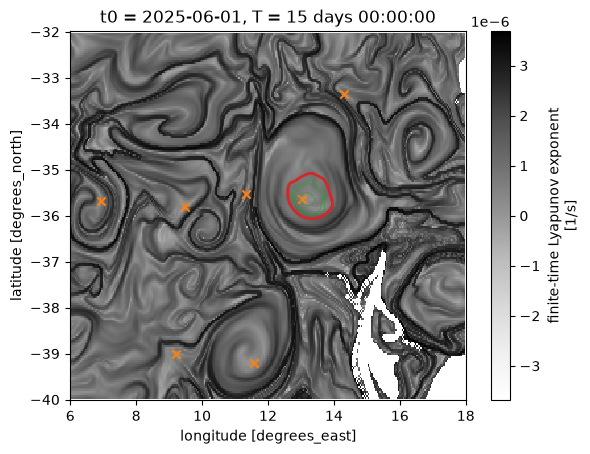

In [26]:
fig, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.scatter(final_centre_lon, final_centre_lat, marker="x", color="tab:orange")
for o in final_orbits:
    ax.plot(
        o["lon"],
        o["lat"],
        "-" if o["sign"] > 0 else "--",
        color="tab:green",
        lw=0.7,
        alpha=0.6,
    )
for o in outermost.values():
    ax.plot(o["lon"], o["lat"], color="tab:red", lw=2.0)
plt.show()

## Validation by advection

$|\nabla F\,\eta_\lambda| = \lambda$ holds pointwise, so any arc tangent to
$\eta_\lambda$ has its arc length multiplied by $\lambda$, whether or not it
closes. Advecting an arc through `flowmap.image()` (which interpolates the
flow map already computed, so no second Parcels run is needed) and
re-measuring its length checks the tangent field and the stepper against
that.

In [27]:
def arc_length_m(lon, lat):
    dx, dy = _separation_m(lon_a=lon[:-1], lat_a=lat[:-1], lon_b=lon[1:], lat_b=lat[1:])
    return np.sum(np.hypot(dx, dy))


def evolve_and_ratio(lon_0, lat_0, flowmap):
    length_0 = arc_length_m(lon_0, lat_0)
    evolved = flowmap.image(
        lon_0=xr.DataArray(lon_0, dims="point"), lat_0=xr.DataArray(lat_0, dims="point")
    )
    lon_1, lat_1 = evolved["lon"].values, evolved["lat"].values
    return arc_length_m(lon_1, lat_1) / length_0, length_0, lon_1, lat_1

The $\eta_\lambda$ lines launched along the section at the outermost
orbit's centre (or, if none closed, the centre whose best launch point
turned furthest), drawn over the FTLE.

In [28]:
if outermost:
    boundary = max(outermost.values(), key=lambda o: o["mean_radius_m"])
    best = {
        "centre_lon": boundary["centre_lon"],
        "centre_lat": boundary["centre_lat"],
        "lam": boundary["lam"],
        "sign": boundary["sign"],
        "s": boundary["s"],
    }
else:
    turns_per_centre = {}
    for record in winding + winding_alt:
        ci = record["centre_idx"]
        if ci not in turns_per_centre or abs(record["turns"]) > abs(
            turns_per_centre[ci]["turns"]
        ):
            turns_per_centre[ci] = record
    best = max(turns_per_centre.values(), key=lambda record: abs(record["turns"]))

s_vals, launch_lon, launch_lat = section_points(
    best["centre_lon"], best["centre_lat"], SECTION_LENGTH_M, N_LAUNCH
)
best_lon, best_lat = trace_eta_lines(
    launch_lon,
    launch_lat,
    lam=best["lam"],
    sign=best["sign"],
    step_m=STEP_M,
    n_steps=N_STEPS,
    tensor_interp=tensor_interp,
)

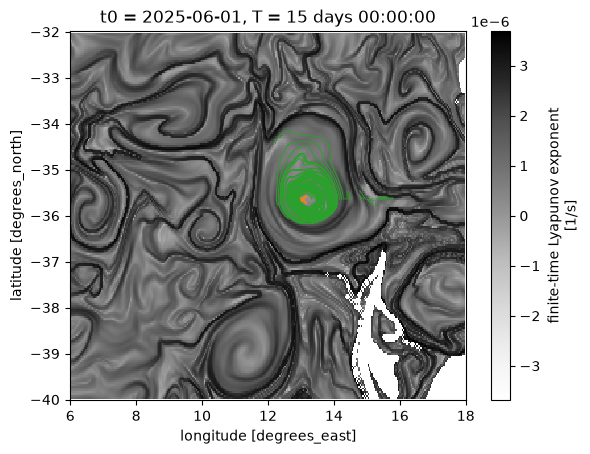

In [29]:
fig, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.plot(best_lon, best_lat, color="tab:green", lw=0.7)
ax.scatter(best["centre_lon"], best["centre_lat"], marker="x", color="tab:orange")
plt.show()

Repeating the advection check for every $\lambda$ of the sweep, from the
same launch point, tests the whole family rather than one member.

In [30]:
launch_dlon = best["s"] / (_M_PER_DEG * np.cos(np.deg2rad(best["centre_lat"])))
arcs = {}
for lam in LAMBDAS_ALL:
    arc_lon, arc_lat = trace_eta_lines(
        np.array([best["centre_lon"] + launch_dlon]),
        np.array([best["centre_lat"]]),
        lam=lam,
        sign=best["sign"],
        step_m=STEP_M,
        n_steps=N_STEPS,
        tensor_interp=tensor_interp,
    )
    finite = np.isfinite(arc_lon[:, 0])
    if finite.sum() >= 10:
        arcs[lam] = (arc_lon[finite, 0], arc_lat[finite, 0])
ratios = {lam: evolve_and_ratio(*arc, forward)[0] for lam, arc in arcs.items()}
ratios

{np.float64(0.8): np.float64(0.7961022265598497),
 np.float64(0.9): np.float64(0.8951862184829621),
 np.float64(0.925): np.float64(0.9412649304513678),
 np.float64(0.95): np.float64(0.9690023928320103),
 np.float64(0.975): np.float64(0.9998607270772056),
 np.float64(1.0): np.float64(1.0168156292666035),
 np.float64(1.025): np.float64(1.01941217502729),
 np.float64(1.05): np.float64(1.0419499674381207),
 np.float64(1.075): np.float64(1.0695636257724475),
 np.float64(1.1): np.float64(1.09315984831364),
 np.float64(1.125): np.float64(1.1185365795899185),
 np.float64(1.15): np.float64(1.1399984599729502),
 np.float64(1.1749999999999998): np.float64(1.1664377733859002),
 np.float64(1.2): np.float64(1.19155236686262),
 np.float64(1.2999999999999998): np.float64(1.296589688053247),
 np.float64(1.4): np.float64(1.4070706705856395)}

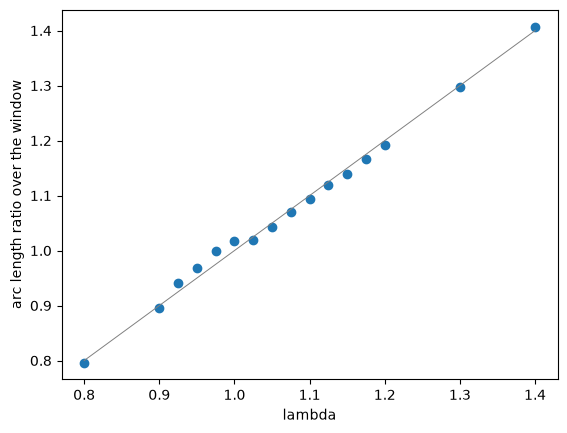

In [31]:
fig, ax = plt.subplots()
ax.plot(list(ratios), list(ratios.values()), marker="o", ls="none")
ax.plot(LAMBDAS_ALL, LAMBDAS_ALL, color="grey", lw=0.7)
ax.set_xlabel("lambda")
ax.set_ylabel("arc length ratio over the window")
plt.show()

The arc traced at the boundary's own $\lambda$, before and after the
window.

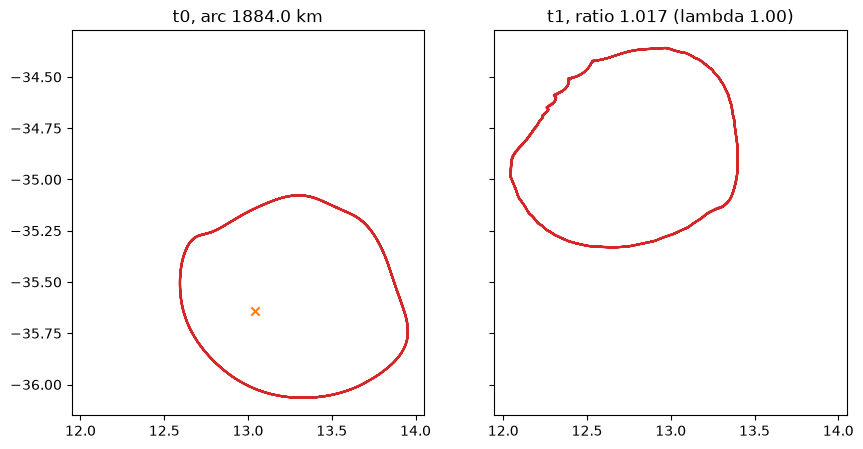

In [32]:
arc_lon, arc_lat = arcs[best["lam"]]
ratio, length_0, evolved_lon, evolved_lat = evolve_and_ratio(arc_lon, arc_lat, forward)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax0.set_title(f"t0, arc {length_0 / 1000:.1f} km")
ax0.plot(arc_lon, arc_lat, color="tab:red")
ax0.scatter(best["centre_lon"], best["centre_lat"], marker="x", color="tab:orange")
ax1.set_title(f"t1, ratio {ratio:.3f} (lambda {best['lam']:.2f})")
ax1.plot(evolved_lon, evolved_lat, color="tab:red")
plt.show()

## Material check: the outermost boundary against a circle

The outermost orbit is claimed to be a material curve stretching uniformly
by its $\lambda$; an arbitrary circle of the same mean radius about the
same centre is not tangent to $\eta_\lambda$ anywhere and has no such claim
on it. Advecting both through `flowmap.image()` and comparing arc-length
ratios tests that claim: the boundary's ratio should sit near its
$\lambda$, the circle's should not.

In [33]:
if outermost:
    boundary_lon, boundary_lat = boundary["lon"], boundary["lat"]

    theta = np.linspace(0.0, 2 * np.pi, len(boundary_lon))
    circle_lon = boundary["centre_lon"] + boundary["mean_radius_m"] * np.cos(theta) / (
        _M_PER_DEG * np.cos(np.deg2rad(boundary["centre_lat"]))
    )
    circle_lat = boundary["centre_lat"] + boundary["mean_radius_m"] * np.sin(theta) / (
        _M_PER_DEG
    )

    boundary_ratio, boundary_length_0, boundary_lon_1, boundary_lat_1 = (
        evolve_and_ratio(boundary_lon, boundary_lat, forward)
    )
    circle_ratio, circle_length_0, circle_lon_1, circle_lat_1 = evolve_and_ratio(
        circle_lon, circle_lat, forward
    )
    material_check = {
        "boundary_lambda": boundary["lam"],
        "boundary_ratio": boundary_ratio,
        "boundary_off_grid_points": int(np.isnan(boundary_lon_1).sum()),
        "circle_ratio": circle_ratio,
        "circle_off_grid_points": int(np.isnan(circle_lon_1).sum()),
    }
else:
    material_check = None
material_check

{'boundary_lambda': np.float64(1.0),
 'boundary_ratio': np.float64(1.0176318741535966),
 'boundary_off_grid_points': 0,
 'circle_ratio': np.float64(1.2097436073588501),
 'circle_off_grid_points': 0}

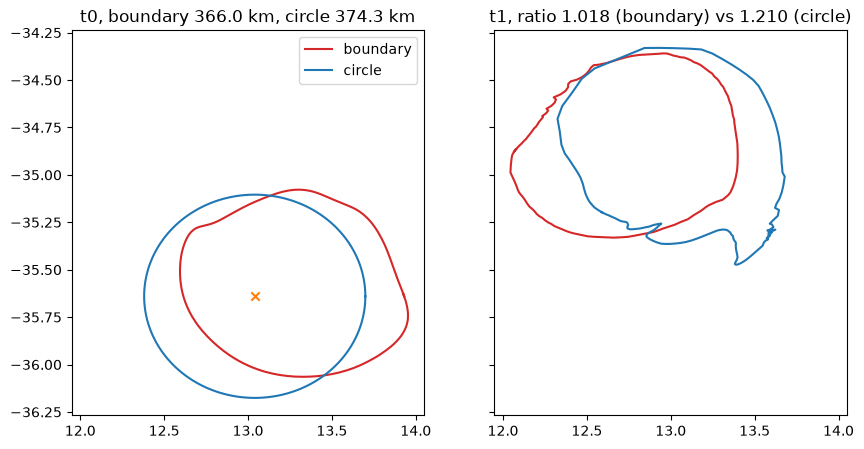

In [34]:
if outermost:
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
    ax0.set_title(
        f"t0, boundary {boundary_length_0 / 1000:.1f} km, "
        f"circle {circle_length_0 / 1000:.1f} km"
    )
    ax0.plot(boundary_lon, boundary_lat, color="tab:red", label="boundary")
    ax0.plot(circle_lon, circle_lat, color="tab:blue", label="circle")
    ax0.scatter(
        boundary["centre_lon"], boundary["centre_lat"], marker="x", color="tab:orange"
    )
    ax0.legend()
    ax1.set_title(
        f"t1, ratio {boundary_ratio:.3f} (boundary) vs {circle_ratio:.3f} (circle)"
    )
    ax1.plot(boundary_lon_1, boundary_lat_1, color="tab:red")
    ax1.plot(circle_lon_1, circle_lat_1, color="tab:blue")
    plt.show()

## Outcome

`find_centres` on $\lambda_2$ (16 centres, window 200 km) turns up nothing:
no launch point at any of those centres completes a full turn, at
$\lambda \in [0.8, 1.4]$ or the denser $[0.9, 1.2]$ scan, and every line
ends on the well-definedness condition rather than the step budget. A
vortex core is where $C \approx I$, not where $\lambda_2$ is smallest, and
the two coincide only when no filament sits between them; here one does,
which is why this selection misses the ring `find_centres` on
$(\lambda_1-1)^2+(\lambda_2-1)^2$ finds.

That second selection (7 centres, window 300 km) closes 4 orbits, all
around the one centre near 13.0 E, -35.6 S: radii of about 21, 39, 45 and
60 km, at $\lambda = 1.1$ for the innermost and $\lambda = 1.0$ for the
other three, all the same sign. The outermost has diameter about 120 km,
inside the 100-300 km range this box targets, and a circumference ratio of
0.98, close to a true circle. That same centre also has the deepest raw
winding of any candidate, above: its best single launch point turns many
times before the well-definedness condition ends it, consistent with a
well-resolved elliptic core rather than a numerical accident. One other C~I
centre (11.56 E, -39.2 S) reaches several turns without closing; the rest
stay under one and never had a chance to.

The material check above supports reading the outermost of the four as a
genuine coherent-vortex boundary: its arc-length ratio, reported there,
lands close to its $\lambda$, while the circle of the same radius and
centre stretches by more, since nothing ties its shape to a uniform-stretch
direction, and neither curve's image leaves the valid grid.